<a href="https://colab.research.google.com/github/too-baa/credit-card-fraud-detection/blob/main/CaseStudy2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Loading and Studying Dataset

In [7]:
import os
import pandas as pd
from google.colab import userdata

#Securely fetch the keys from your Colab vault
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

#Download and unzip the dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

df = pd.read_csv("creditcard.csv")


Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 164MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [8]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [30]:
print(df.shape)

(284807, 31)


In [9]:
print(df.head())
print(df.isnull().sum())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

2. Splitting Dataset

In [10]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=["Class"], axis=1)
y=df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#checking for class distribution
print("Normal Cases: ", sum(y_train == 0))
print("Fraud Cases: ", sum(y_train == 1))

Normal Cases:  227451
Fraud Cases:  394


3. Applying SMOTE

In [19]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [16]:
print("Normal cases: ", sum(y_train_smote==0))
print("Fraud cases: ", sum(y_train_smote==1))

Normal cases:  227451
Fraud cases:  227451


4. Training XGBoost and checking Feature Importance


In [20]:
import xgboost as xgb
import matplotlib.pyplot as plt

model=xgb.XGBClassifier(random_state=42)

model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

<Figure size 1000x800 with 0 Axes>

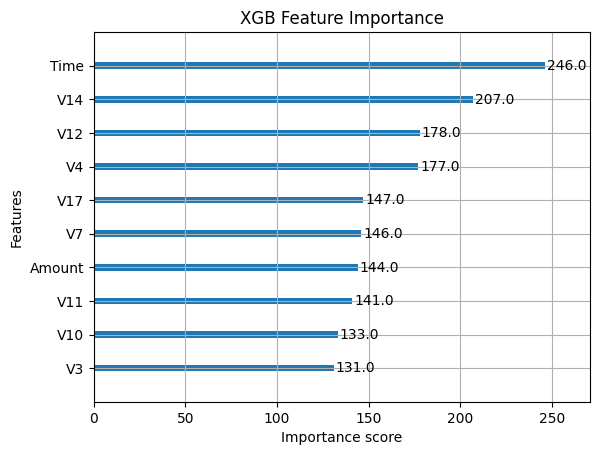

In [22]:
plt.figure(figsize=(10,8))
xgb.plot_importance(model, max_num_features=10)
plt.title("XGB Feature Importance")
plt.show()

5. Prediction

In [28]:
probabilities= model.predict_proba(X_test)[:,1]

custom_threshold = 0.30

y_pred = (probabilities >= custom_threshold).astype(int)

6. Evaluating Model

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("\nClassification Report", classification_report(y_test,y_pred))

Confusion Matrix:
 [[56843    21]
 [   14    84]]

Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

